In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
x = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [5]:
print(heart_disease.shape)

None


In [3]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

In [4]:
# 2. Prétraitement
X = heart_disease.data.features 
y = heart_disease.data.targets               # Label (0 = sain, 1 = malade)
y = (y > 0).astype(int)   # 0 = sain, 1 = malade (peu importe le degré)
y = y.values.ravel()      # corrige aussi le DataConversionWarning

# fitting the missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

#normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


# logistic regression
models ={         
        'logistic_reg':  LogisticRegression(max_iter=1000),
         'random_forest': RandomForestClassifier(n_estimators = 100, random_state= 42),
         'scv' : SVC(kernel = 'linear', probability = True, random_state= 42)
}

result = {}
for name, model in models.items():
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1] if hasattr(model,"predict_proba") else None

    result[name]={
            "Accuracy" : accuracy_score(y_test, pred),
            "F1-score" : f1_score(y_test,pred),
            "ROC-AUC" : roc_auc_score(y_test,prob) if prob is not None else "N/A",
            "Confusion Matrix" :confusion_matrix(y_test,pred)
    } 

for name, matrics in result.items():
    print(f"\n=== {name} ===")
    for matric, value in matrics.items():
        print(f"{matric}: {value}")


=== logistic_reg ===
Accuracy: 0.8852459016393442
F1-score: 0.8923076923076924
ROC-AUC: 0.9191810344827586
Confusion Matrix: [[25  4]
 [ 3 29]]

=== random_forest ===
Accuracy: 0.8852459016393442
F1-score: 0.8888888888888888
ROC-AUC: 0.9407327586206897
Confusion Matrix: [[26  3]
 [ 4 28]]

=== scv ===
Accuracy: 0.9016393442622951
F1-score: 0.90625
ROC-AUC: 0.9342672413793103
Confusion Matrix: [[26  3]
 [ 3 29]]


In [9]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model,X_scaled, y, cv=5, scoring='accuracy')
from sklearn.model_selection import cross_val_score

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='f1')
    cv_results[name] = {
        "mean_f1": scores.mean(),
        "std_f1": scores.std(),
        "all_folds": scores
    }

for name, res in cv_results.items():
    print(f"\n=== {name} ===")
    print(f"Mean F1: {res['mean_f1']:.4f}  (± {res['std_f1']:.4f})")
    print(f"All folds: {res['all_folds']}")


=== logistic_reg ===
Mean F1: 0.8045  (± 0.0433)
All folds: [0.83018868 0.87719298 0.77966102 0.7755102  0.76      ]

=== random_forest ===
Mean F1: 0.7965  (± 0.0611)
All folds: [0.84615385 0.88135593 0.79310345 0.71698113 0.74509804]

=== scv ===
Mean F1: 0.7954  (± 0.0435)
All folds: [0.8        0.87719298 0.77966102 0.76       0.76      ]


In [12]:
from sklearn.model_selection import cross_validate

scoring = ['accuracy', 'f1', 'roc_auc']
cv_results = {}
for name, model in models.items():
    scores = cross_validate(model, X_scaled, y, cv=5, scoring=scoring)
    cv_results[name] = {
        metric: scores[f'test_{metric}'].mean() for metric in scoring
    }

for name, res in cv_results.items():
    print(f"\n=== {name} ===")
    for metric, value in res.items():
        print(f"{metric}: {value:.4f}")


=== logistic_reg ===
accuracy: 0.8283
f1: 0.8045
roc_auc: 0.9016

=== random_forest ===
accuracy: 0.8181
f1: 0.7965
roc_auc: 0.9001

=== scv ===
accuracy: 0.8184
f1: 0.7954
roc_auc: 0.9022


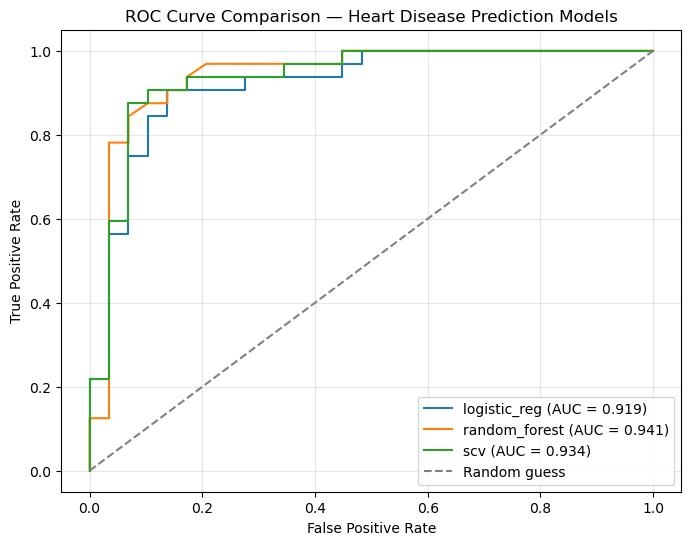

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for name, model in models.items():
    model.fit(X_train, y_train)  # reuse your existing train/test split
    y_prob = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# reference diagonal (random guessing)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Heart Disease Prediction Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()